In [2]:
import IPython.display as ipd

import os, sys
current_path = os.getcwd()
path_parts = current_path.split(os.sep)
idx = path_parts.index("occupancy-estimation")
homepath = os.sep.join(path_parts[:idx + 1]) +"/"
sys.path.append(homepath)

# import pandas as pd
# import matplotlib.pyplot as plt
# import reciprocalspaceship as rs
# from occupancy import *
# from plotting3d import *
%load_ext autoreload 
%autoreload 2


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from meteor import rsmap
from meteor.utils import cut_resolution

from meteor.diffmaps import compute_difference_map, max_negentropy_kweighted_difference_map
from meteor.tv import tv_denoise_difference_map
from meteor.validate import map_negentropy

In [28]:
# from photolyase import *
from photolyase import get_exp_structure_factors, calculate_dog_filter_mask_v2, ccp4_to_mask
from compare_conds import get_intersect_and_angle
from photolyase import get_hists, plot_hists, find_wasserstein_dip
from plotting3d import slice_3d, add_fit
from meteorize import *



In [5]:
%matplotlib inline
%matplotlib widget

In [6]:
folderloc =  homepath+'../photolyase_share_reviewers/'
dataloc_dark  = folderloc + '1_superdark/superdark_deposit.mtz'
pdbloc_dark  = folderloc + '1_superdark/superdark_deposit.pdb'
dataloc_light = folderloc + "6_10ns/10ns_deposit.mtz"
pdbloc_light  = folderloc + '6_10ns/10ns_deposit.pdb'
dataloc_light = folderloc + "7_30ns/30ns_deposit.mtz"
pdbloc_light  = folderloc + '7_30ns/30ns_deposit.pdb'

mask_loc_sphere = homepath+"../photolyase_masks/photolyase_TT_chainA_spherical_mask.ccp4"
mask_loc_handcraft = homepath+"../photolyase_masks/photolyase_chainA_spherical_masks.ccp4"
hs_limit = 2.4 
map_sampling = 3




# Data Preparation

## Obtaining F and rho from real data

In [7]:
ds_light = rs.read_mtz(dataloc_light)
ds_dark = rs.read_mtz(dataloc_dark)

ds_dark = cut_resolution(ds_dark,high_resolution_limit=hs_limit)
ds_light = cut_resolution(ds_light,high_resolution_limit=hs_limit)



In [8]:
map_dark, map_light = get_scaled_maps(ds_dark, ds_light)



Running scaleit, see tmp/launch_scaleit.sh


## Obtaining diffmaps

In [9]:
make_dict = lambda **kwargs:kwargs
diffmap_config = make_dict(
    direct_realspace = make_dict(
        title= "Direct Realspace Subtraction",
        loader= calc_direct_difference,
        kwargs=make_dict(map_sampling=map_sampling),
    ),
    
    vanilla_diffmap = make_dict(
        title= "Vanilla Isomorphous DiffMap",
        loader = compute_difference_map,
        kwargs = {}
    ),
    kweighted = make_dict(
        title= "K-weighted Difference Map",
        loader = fetch_without_meta,
        kwargs = make_dict(diffmap_maker=max_negentropy_kweighted_difference_map)
    ),
    tv = make_dict(
        title= "TV-denoised Difference Map",
        loader = fetch_tv_denoised,
    ),
)


In [10]:
map_types = [
    'direct_realspace',
    'vanilla_diffmap',
    'kweighted',
    'tv',
]
diffmaps={}
for key in map_types:
    config = diffmap_config[key]
    loader = config['loader']
    kwargs = config.get('kwargs',{})
    diffmaps[key] = loader(map_light,map_dark, **kwargs)

### visualize tv denoising

In [ ]:
if False:

    vanilla_diffmap=diffmaps['diffmap']
    initial_negentropy = map_negentropy(vanilla_diffmap)
    print(f"initial negentropy: {initial_negentropy:.5f}")

    kewighted_negentropy = map_negentropy(k_weighted_diffmap)

    print(f"optimal k-parameter: {kparameter_metadata.optimal_parameter_value}")
    print(f"negentropy: {kewighted_negentropy:.5f}")
    tv_denoised_map, metadata = tv_denoise_difference_map(k_weighted_diffmap, full_output=True)
    plt.figure(figsize=(8, 3))

    plt.xlabel("TV weight")
    plt.ylabel("map negentropy")
    plt.xscale("log")

    # points are not sampled in order of increasing TV weight, so we have to order them
    tv_weights_scanned = [pt.parameter_value for pt in metadata.parameter_scan_results]
    negentropy_at_weights = [pt.objective_value for pt in metadata.parameter_scan_results]
    sort_order = np.argsort(tv_weights_scanned)

    plt.plot(
        np.array(tv_weights_scanned)[sort_order],
        np.array(negentropy_at_weights)[sort_order],
    )

    plt.scatter(
        tv_weights_scanned,
        negentropy_at_weights,
        edgecolors="darkblue",
        linewidths=1,
        alpha=0.7,
    )

    plt.hlines(metadata.initial_negentropy, 0, 0.05, color="black", linestyle="dashed")
    plt.vlines(metadata.optimal_parameter_value, -0.01, 0.10, color="black", linestyle="dashed")
    # plt.ylim([0, 0.10])

    plt.show()


### How I calculate f_diff usually

In [90]:
f_dark, f_light = get_exp_structure_factors(ds_dark, ds_light)
f_angle = np.angle(f_dark)

f_dark_abs = np.abs(f_dark)
f_light_abs = np.abs(f_light)
delta_f = (f_light_abs - f_dark_abs) 
delta_f_with_phase = delta_f * np.exp(1j * f_angle)
delta_rho_f = np.fft.ifftn(delta_f_with_phase).real
# slice_3d()

Running scaleit, see tmp/launch_scaleit.sh


interactive(children=(IntSlider(value=0, description='f0', max=89), Output()), _dom_classes=('widget-interact'…

(90, 150, 216)

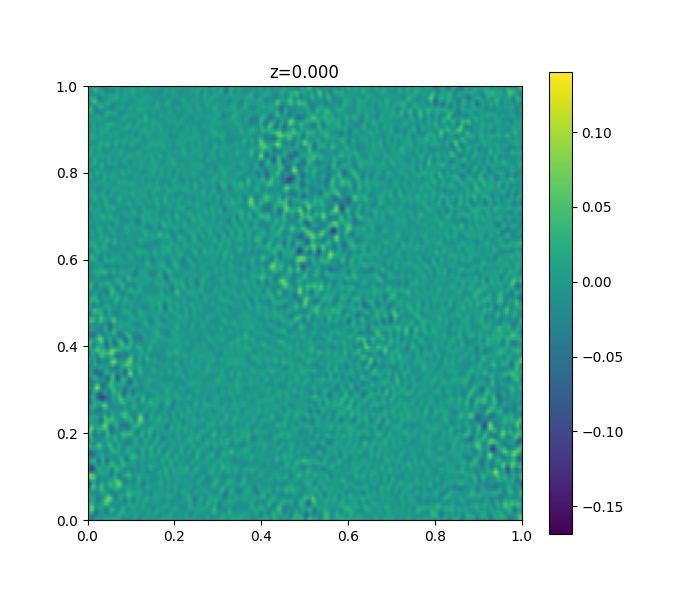

In [99]:
slice_3d(delta_rho_f)
delta_rho_f.shape

### overview

interactive(children=(IntSlider(value=45, description='f0', max=89), Output()), _dom_classes=('widget-interact…

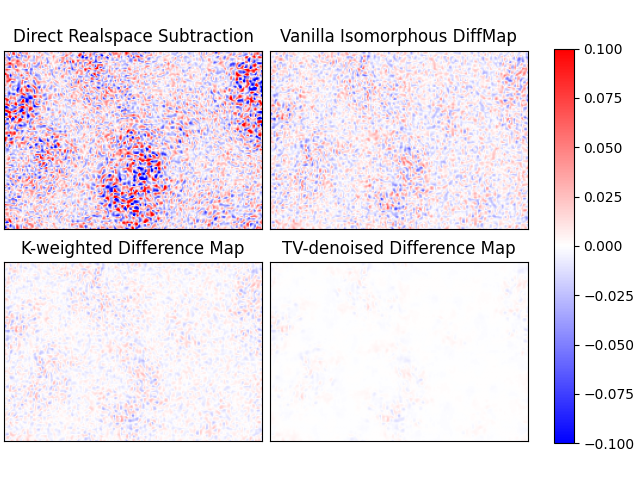

In [11]:
axtitles = [diffmap_config[key]["title"] for key in diffmaps.keys()]
diffmaps_np = [diffmap.to_3d_numpy_map(map_sampling=map_sampling)
               for diffmap in diffmaps.values()]
from output_eval import panels_3d

_ = panels_3d(diffmaps_np, imkwargs={"cmap":'bwr', "vmax":.1, "vmin":-.1},figkwargs={'nrows':2,'ncols':2}, axtitles=axtitles)

# Getting Masks

In [12]:
def mask_highest_values(
        rho_delta, 
        perc_size = 1e-4,
):
    # rho_delta=diffmap.
    perc_high = np.percentile(rho_delta,100-perc_size)
    perc_low = np.percentile(rho_delta,perc_size)
    mask_truth = np.logical_or(rho_delta>perc_high, rho_delta<perc_low)
    return mask_truth

     # calculate_dog_filter_mask_v2(,)
                                  
unit = np.array((
    map_dark.cell.a,
    map_dark.cell.b,
    map_dark.cell.c
))

In [13]:
rho_diff = diffmaps['tv'].to_3d_numpy_map(map_sampling=map_sampling)
step_size = np.array(rho_diff.shape)/ unit


In [14]:

mask_configs = {
    "dog": {
        "title": "DoG (Measurement)",
        "loader": calculate_dog_filter_mask_v2,
        "kwargs": make_dict(
            nth_val = 40*2**3,
            target_shape = np.array(rho_diff.shape),
            sigma = np.mean(step_size) * 1.75,
            thresh_pos = 0.35,
            thresh_neg = 0.5,
        )
    },
    "pseudo-z": {
        "title": "largest and smallest values \n(0.01%) (PDB deposited)",
        "loader": mask_highest_values,
        "kwargs": make_dict(
            perc_size = 1e-2,
        )
            
    },
    "ball": {
        "title": "Ball of Interest",
        "loader": lambda x: ccp4_to_mask(mask_loc_sphere, rho_diff.shape),
    },
    "handpicked": {
        "title": "Hand picked Mask",
        "loader": lambda x: ccp4_to_mask(mask_loc_handcraft, rho_diff.shape),
    },
    "nomask": {
        "title": "No Mask",
        "loader": lambda x: np.ones(rho_diff.shape, bool),
    }
}

In [15]:
mask_types = [
        "dog",
        "pseudo-z",
        "ball",
        "handpicked",
        "nomask",
    ]
masks={}
for key in mask_types:
    config = mask_configs[key]
    loader = config['loader']
    kwargs = config.get('kwargs',{})
    masks[key] = loader(rho_diff, **kwargs)


dogged
0.0006288273376412689 {424: 182, 87: 182, 206: 181, 86: 182, 90: 182, 210: 181, 91: 182, 115: 125, 116: 125, 15: 96, 346: 182, 110: 166, 345: 182, 109: 166, 412: 163, 359: 163, 180: 154, 527: 70, 532: 70, 358: 163, 189: 164, 531: 70, 528: 70}
0.0006703285616822541 {415: 176, 563: 80, 104: 80, 379: 80, 115: 80, 176: 175, 573: 80, 257: 87, 197: 77, 416: 176, 471: 80, 114: 80, 430: 78, 377: 80, 574: 80, 192: 52, 267: 80, 196: 77, 105: 80, 258: 87, 433: 78, 564: 80, 271: 80, 408: 177, 177: 175, 149: 176, 12: 80, 395: 92, 133: 86, 2: 60, 461: 92, 462: 92, 1: 60}


interactive(children=(IntSlider(value=0, description='f0', max=89), Output()), _dom_classes=('widget-interact'…

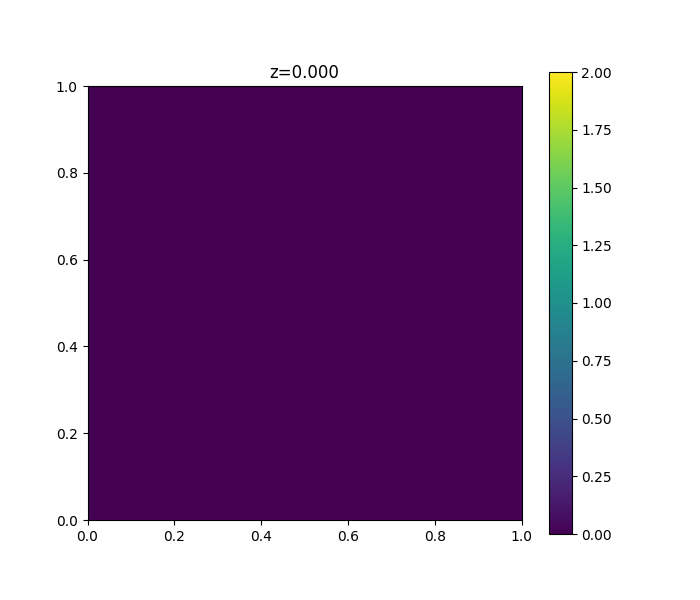

In [20]:
%matplotlib widget
_ =slice_3d(masks['pseudo-z'], imkwargs={'vmax':2})

In [21]:
np.sum(masks['pseudo-z'])

584

# Calculating rho_xtr


In [22]:
# from plotting3d import *

%matplotlib inline


In [23]:
# Make choices for what to plot 
diffmap_key = 'kweighted'
mask_key = 'handpicked'

diffmap = diffmaps[diffmap_key]
mask4 = masks[mask_key]



In [24]:
extrapolation_factors = np.arange(1,100,10)
extrapolation_factors3 = np.linspace(63,69,5)-30
extrapolation_factors3 = np.linspace(21.5,49,20)
extrapolation_factors2 = np.linspace(150,600,5)
extrapolation_factors2 = [5,9,15]
extrapolation_factors = np.sort(np.concatenate([extrapolation_factors, extrapolation_factors2, extrapolation_factors3]))

rho_xtrs =  make_real_space_xtr(map_dark, diffmap, extrapolation_factors, map_sampling, ) 
map_xtrs = make_k_space_xtr(map_dark, diffmap, extrapolation_factors)

diffmax = (np.max(diffmap.to_3d_numpy_map(map_sampling=map_sampling)))
darkmax = (np.max(map_dark.to_3d_numpy_map(map_sampling=map_sampling)))
print(darkmax,diffmax,darkmax/diffmax)



2.6091971 0.064310804 40.57168


In [25]:
neg_sums = []
neg_sum_real_space = negsum_meteor(rho_xtrs, map_sampling=map_sampling, mask=mask4) 
neg_sum_map = negsum_meteor(map_xtrs, map_sampling=map_sampling, mask=mask4) 

n_largest = 3

In [26]:

dens_xtrs = [map_xtr.to_3d_numpy_map(map_sampling=map_sampling) for map_xtr in map_xtrs]
rho_dark = map_dark.to_3d_numpy_map(map_sampling=map_sampling)
rmin= np.min(rho_dark)
rmax= np.max(rho_dark)
offset = (rmax-rmin)*0.2
bins = np.linspace(rmin-offset,rmax+offset,100)

dhists, lhists, wdists, bin_centers = get_hists(dens_xtrs, rho_dark, mask4, bins)

hist 37.421052631578945
intersection point, 0.080 (24.94)


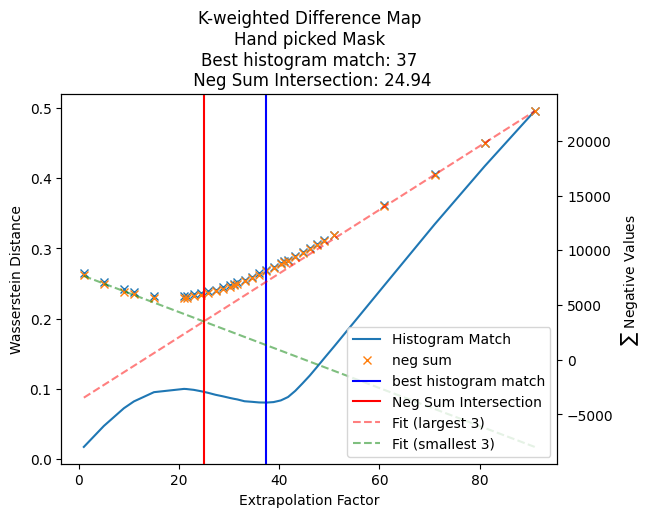

In [ ]:
best_values = {}
fig, ax2 = plt.subplots() 
ln1 = ax2.plot(extrapolation_factors, wdists, label="Histogram Match")


ax = ax2.twinx()
title_str = ""
title_str += diffmap_config[diffmap_key]['title']+'\n'
title_str += mask_configs[mask_key]['title']
ax.plot(extrapolation_factors, -neg_sum_real_space, 'x')
ax.plot(extrapolation_factors, -neg_sum_map, 'x', label='neg sum')

xvalue = find_wasserstein_dip(extrapolation_factors,wdists)
if xvalue:
    print('hist', xvalue)
    best_values['hist']=(xvalue)
    ax.axvline(xvalue, color="blue", label="best histogram match")
    title_str += f"\nBest histogram match: {xvalue:.0f}"  

if n_largest:
    intersect, angle = get_intersect_and_angle(extrapolation_factors, neg_sum_map, n_largest)
    ax.axvline(intersect, color="red", label="Neg Sum Intersection")
    add_fit(neg_sum_map, extrapolation_factors, n_largest, ax=ax)
    best_values['intersect']=(intersect)
    title_str += f"\n Neg Sum Intersection: {intersect:.2f}"  
lns = [ l for l in ax.lines if l.get_label()[0]!="_"]
lns =  ln1 + lns
labs = [l.get_label() for l in lns ]

ax2.set_ylabel('Wasserstein Distance')
ax2.set_xlabel('Extrapolation Factor')
ax2.set_yscale('log')
ax.set_ylabel(r'$\sum$ Negative Values')
    
ax.legend(lns,labs, loc='lower right')
ax.set_title(title_str)
plt.show()

Text(0.5, 0.98, 'K-weighted Difference Map\nHand picked Mask\nBest histogram match: 34')

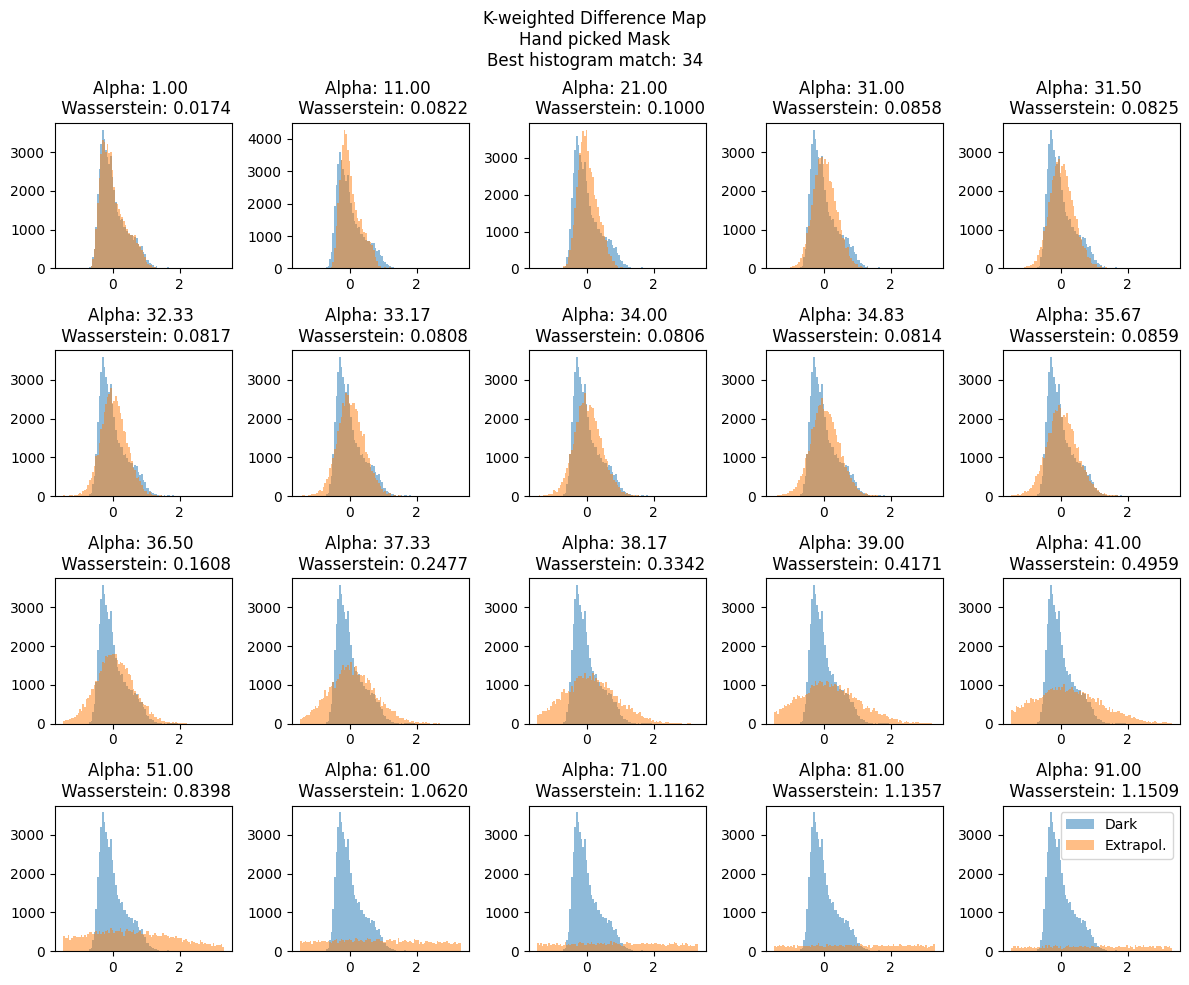

In [367]:

fig,ax1 = plot_hists(dhists, lhists, wdists, bin_centers, extrapolation_factors)
title_str = ""
title_str += diffmap_config[diffmap_key]['title']+'\n'
title_str += mask_configs[mask_key]['title']
title_str += f"\nBest histogram match: {xvalue:.0f}"  
fig.suptitle(title_str)


In [268]:
my_vals = [61,66,71]
map_xtrs_best = make_k_space_xtr(map_dark, diffmap, best_values.values())
for ii,key in enumerate(best_values.keys()):
    name=f"pl_30_tv_xtr{key}.mtz"
    map_xtrs_best[ii].write_mtz(name)